IMPORTS

In [170]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

LOAD DATASET


In [171]:
data = pd.read_csv('/content/insurance.csv')
df= pd.DataFrame(data)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


CHECK DATA TYPE AND NULL VALUES

In [172]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


CHECK ALL CATEGORICAL VALUES

In [173]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [174]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [175]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

ENCODE CATEGORICAL VALUES

In [176]:
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['region'], drop_first=True)

ADDING FEATURES OF HIGH IMPORTANCE

In [177]:
df['age_smoker'] = df['age'] * df['smoker']
df['bmi_smoker'] = df['bmi'] * df['smoker']

TRAIN TEST SPLIT

In [178]:
X = df.drop(columns='charges',axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)

  RANDOM FOREST + GRIDSEARCH

In [179]:
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [10, 14, 18],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}
rf = RandomForestRegressor(random_state=42)
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

FEATURE IMPORTANCE METRICS

In [180]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

            Feature  Importance
9        bmi_smoker    0.341393
8        age_smoker    0.229489
4            smoker    0.209039
0               age    0.110518
2               bmi    0.080574
3          children    0.014930
1               sex    0.004312
6  region_southeast    0.003623
5  region_northwest    0.003286
7  region_southwest    0.002835


DROP IRRELEVANT FEATURES

In [181]:
low_importance_features = importance_df[importance_df['Importance'] < 0.01]['Feature'].tolist()
print("Dropping features:", low_importance_features)

Dropping features: ['sex', 'region_southeast', 'region_northwest', 'region_southwest']


MODEL TRAINING

In [182]:
X_reduced = X.drop(columns=low_importance_features)
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=200)
final_rf = RandomForestRegressor(n_estimators=800,max_depth=10,min_samples_leaf=2,min_samples_split=2,max_features=0.7,random_state=42)
final_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features=0.7, min_samples_leaf=2,
                      n_estimators=800, random_state=42)

PREDICTION

In [183]:
y_pred = final_rf.predict(X_test)

METRICS

In [184]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2345.3433720121593
RMSE: 4472.288024246402
R2: 0.8722076683741571


MODEL VISUALIZATIONS

1️⃣ Target Variable Distribution (Charges)

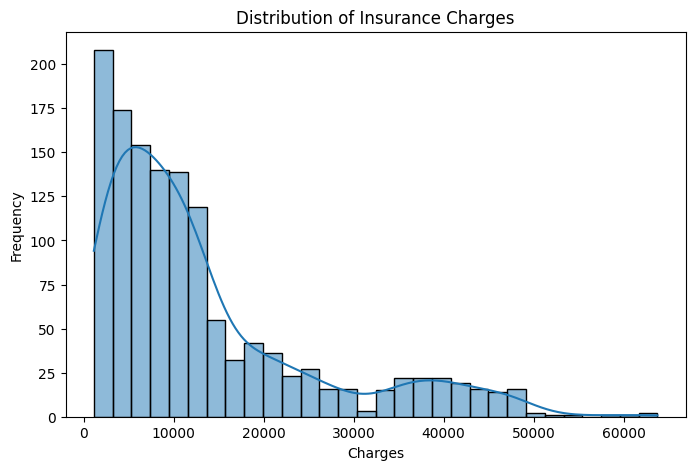

In [187]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

2️⃣ Correlation Heatmap (EDA Summary)

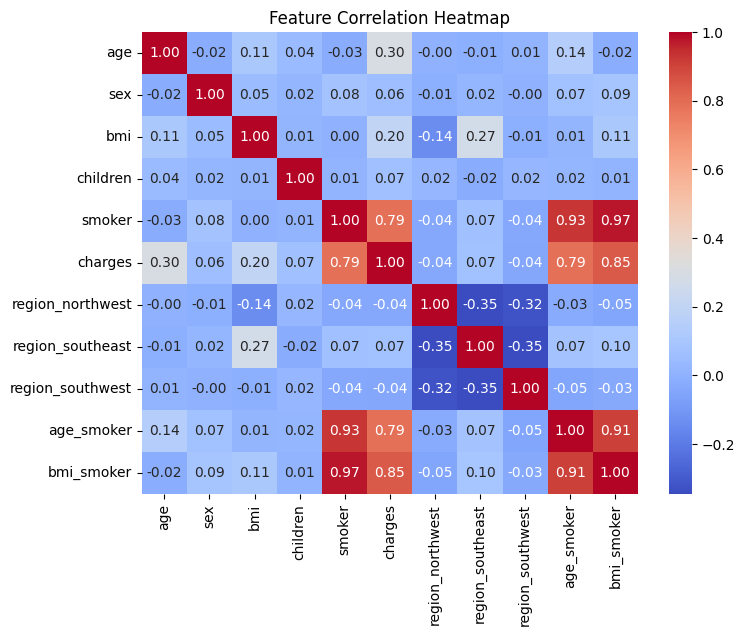

In [188]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

3️⃣ Actual vs Predicted (MOST IMPORTANT)

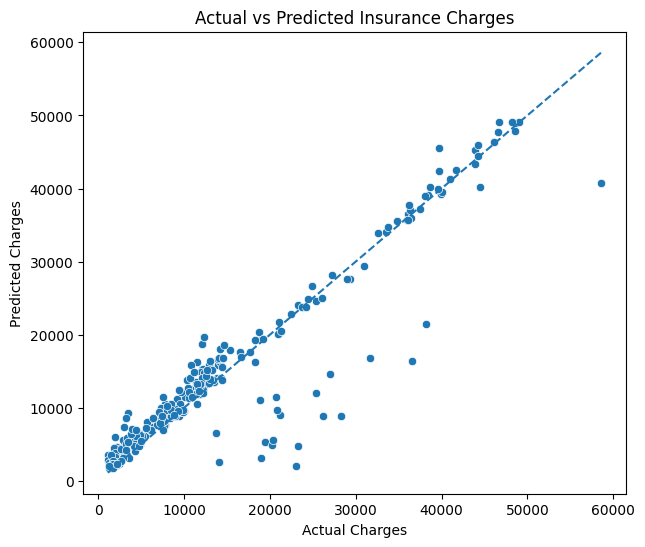

In [189]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linestyle='--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

4️⃣ Residual Distribution

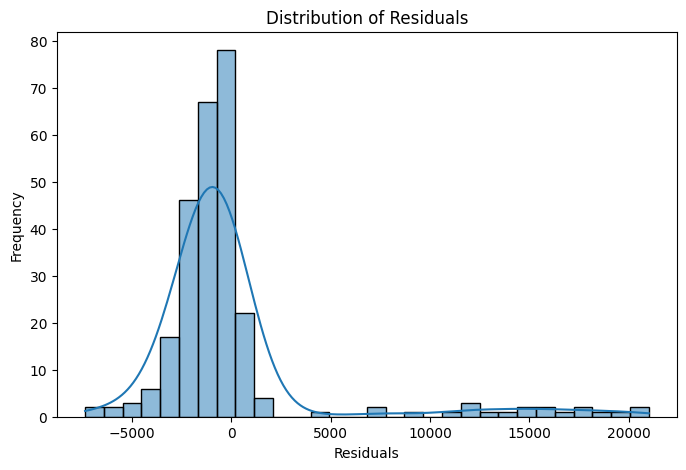

In [190]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

5️⃣ Feature Importance

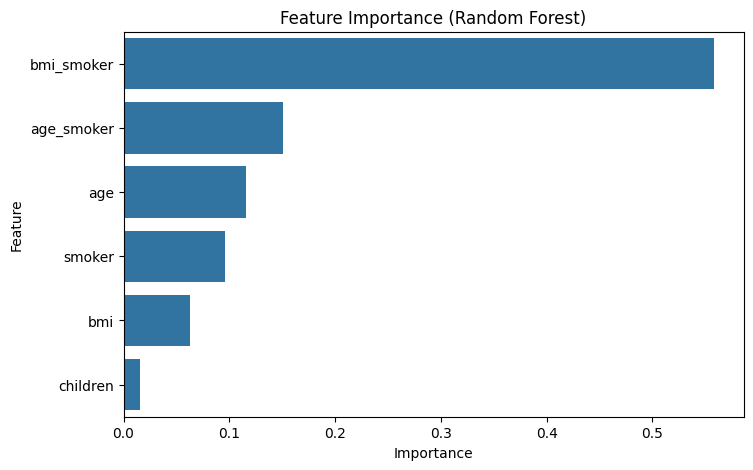

In [191]:
importance_df = pd.DataFrame({'Feature': X_reduced.columns,'Importance': final_rf.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=importance_df,x='Importance',y='Feature')
plt.title("Feature Importance (Random Forest)")
plt.show()